# TEMA/CMO eth — Productie (vol-target 40%)

Gevalideerde versie. Wijzigingen t.o.v. de oude all-in notebook:
- **Position sizing: volatility-targeting 40%** (positie = 40% / gerealiseerde vol, gecapt op 100%, geen hefboom)
- **Fees 0,2% per kant** en **slippage 0,1% op stop-exits** meegerekend
- Kolomnaam opgeschoond (`TEMA`, geen misleidende `TEMA_130` meer) en win% wordt nu direct in de hoofdloop bijgehouden

Parameters: TEMA 100 / CMO>10 / ATR×3,5 / vol-target 40%.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ============ 1. Data laden ============
df = pd.read_csv('eth_1d.csv')
df['date'] = pd.to_datetime(df['timestamp']).dt.date
df = df.sort_values('date').reset_index(drop=True)

# ============ 2. Indicator-functies ============
def tema(series, length):
    ema1 = series.ewm(span=length, adjust=False).mean()
    ema2 = ema1.ewm(span=length, adjust=False).mean()
    ema3 = ema2.ewm(span=length, adjust=False).mean()
    return 3*(ema1 - ema2) + ema3

def cmo(series, window):
    delta = series.diff()
    up = delta.clip(lower=0).rolling(window).sum()
    down = (-delta.clip(upper=0)).rolling(window).sum()
    return 100*(up - down)/(up + down)

# ============ 3. Indicatoren berekenen ============
df['TEMA'] = tema(df['close'], 120)   # trendlijn
df['CMO']  = cmo(df['close'], 14)     # momentumfilter

# ATR voor de trailing stop
high_low = df['high'] - df['low']
high_cp  = (df['high'] - df['close'].shift(1)).abs()
low_cp   = (df['low']  - df['close'].shift(1)).abs()
tr = pd.concat([high_low, high_cp, low_cp], axis=1).max(axis=1)
df['ATR'] = tr.rolling(14).mean()

# Gerealiseerde volatiliteit (30d) voor vol-targeting
df['VOL'] = df['close'].pct_change().rolling(30).std()

df = df.dropna().reset_index(drop=True)
print(f"\u2705 Data geladen: {len(df)} dagen, {df['date'].iloc[0]} t/m {df['date'].iloc[-1]}.")

✅ Data geladen: 2686 dagen, 2019-01-31 t/m 2026-06-08.


In [7]:
# ============ 4. Backtest met vol-targeting + fees + slippage ============
# --- PRODUCTIE PARAMETERS (gevalideerd) ---
cmo_trigger    = 10
atr_multiplier = 3.5
fee            = 0.002     # 0,2% per kant
slippage       = 0.001     # 0,1% extra verlies op stop-fill
target_vol     = 0.40      # vol-targeting niveau
f_min, f_max   = 0.10, 1.0 # positiegrootte-grenzen (geen hefboom)

cash = 1000.0
eth_holding = 0.0
in_position = False
stop_loss_price = 0.0
highest_price_in_trade = 0.0
entry_value = 0.0
trade_count = 0
portfolio_history = []
trades = []   # (entry_value, exit_value) per gesloten trade

for i in range(len(df)):
    row = df.iloc[i]
    price  = row['close']; tema_v = row['TEMA']; cmo_v = row['CMO']
    atr_v  = row['ATR'];   vol_v  = row['VOL'];  date  = row['date']

    total_value = cash + eth_holding*price
    portfolio_history.append({'date': date, 'total_value': total_value})

    # 1) EXIT: stop geraakt (slippage + fee)
    if in_position and price <= stop_loss_price:
        fill = price*(1 - slippage)
        cash += eth_holding*fill*(1 - fee)
        eth_holding = 0.0
        in_position = False
        trades.append((entry_value, cash))
        print(f"[{date}] \u274c EXIT #{trade_count}: stop @ \u20ac{price:,.0f} -> saldo \u20ac{cash:,.0f}")
        continue

    # 2) Trailing stop bijwerken
    if in_position:
        if price > highest_price_in_trade:
            highest_price_in_trade = price
        pot = highest_price_in_trade - atr_multiplier*atr_v
        if pot > stop_loss_price:
            stop_loss_price = pot

    # 3) ENTRY met vol-targeting positiegrootte
    if (not in_position) and price > tema_v and cmo_v > cmo_trigger:
        vol_ann = vol_v*np.sqrt(365)
        fraction = min(f_max, max(f_min, target_vol/vol_ann)) if vol_ann > 0 else f_max
        entry_value = total_value
        invest = cash*fraction
        eth_holding = invest*(1 - fee)/price
        cash -= invest                       # reserve blijft als cash staan
        in_position = True
        highest_price_in_trade = price
        stop_loss_price = price - atr_multiplier*atr_v
        trade_count += 1
        print(f"[{date}] \U0001f680 ENTRY #{trade_count}: koop @ \u20ac{price:,.0f} "
              f"| vol {vol_ann*100:.0f}% -> inzet {fraction*100:.0f}% (CMO {cmo_v:.0f})")

eind_waarde = cash + eth_holding*df.iloc[-1]['close']
print(f"\n\U0001f4ca BACKTEST VOLTOOID.")
print(f"Trades: {trade_count} | Eindwaarde: \u20ac{eind_waarde:,.2f}")

[2019-02-10] 🚀 ENTRY #1: koop @ €125 | vol 85% -> inzet 47% (CMO 29)
[2019-03-04] ❌ EXIT #1: stop @ €126 -> saldo €1,000
[2019-03-16] 🚀 ENTRY #2: koop @ €141 | vol 90% -> inzet 44% (CMO 19)
[2019-07-11] ❌ EXIT #2: stop @ €269 -> saldo €1,396
[2019-09-15] 🚀 ENTRY #3: koop @ €189 | vol 54% -> inzet 74% (CMO 42)
[2019-09-24] ❌ EXIT #3: stop @ €166 -> saldo €1,264
[2019-10-08] 🚀 ENTRY #4: koop @ €181 | vol 86% -> inzet 47% (CMO 22)
[2019-10-24] ❌ EXIT #4: stop @ €160 -> saldo €1,196
[2019-10-29] 🚀 ENTRY #5: koop @ €190 | vol 77% -> inzet 52% (CMO 14)
[2019-11-21] ❌ EXIT #5: stop @ €161 -> saldo €1,097
[2019-12-08] 🚀 ENTRY #6: koop @ €150 | vol 57% -> inzet 70% (CMO 30)
[2019-12-16] ❌ EXIT #6: stop @ €133 -> saldo €1,002
[2019-12-31] 🚀 ENTRY #7: koop @ €129 | vol 61% -> inzet 66% (CMO 17)
[2020-02-26] ❌ EXIT #7: stop @ €224 -> saldo €1,481
[2020-04-06] 🚀 ENTRY #8: koop @ €171 | vol 224% -> inzet 18% (CMO 50)
[2020-09-03] ❌ EXIT #8: stop @ €381 -> saldo €1,802
[2020-10-22] 🚀 ENTRY #9: koop @

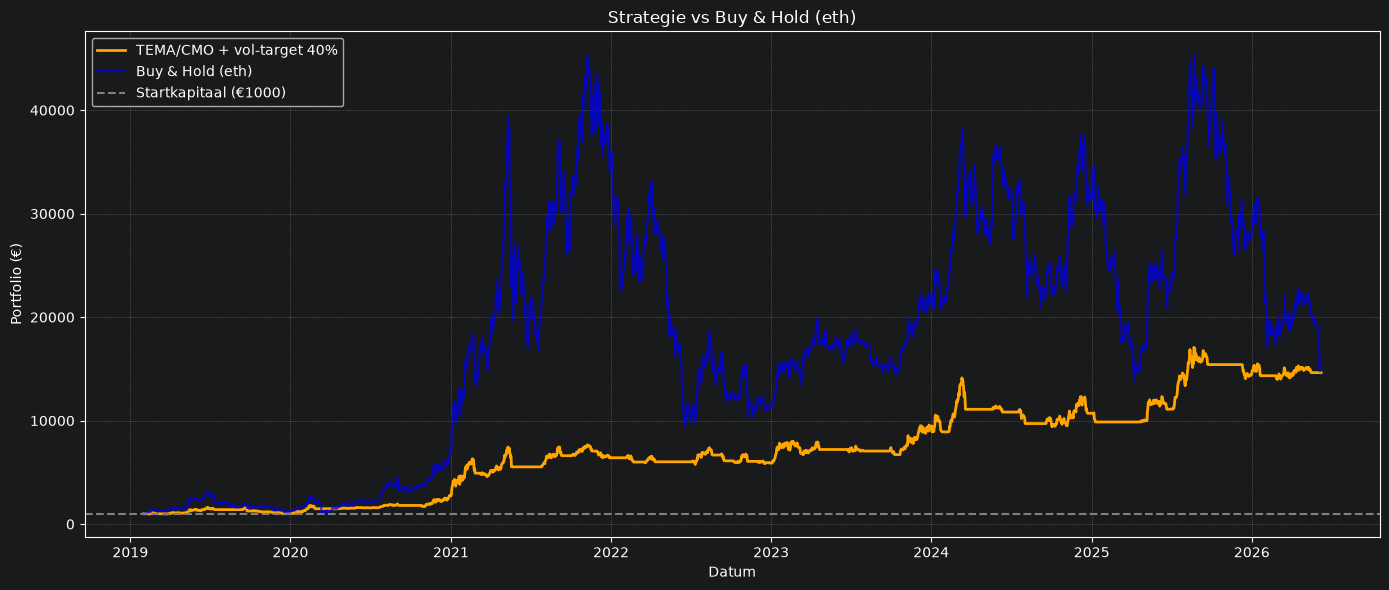

In [8]:
# ============ 5. Equity curve vs Buy & Hold (lineair) ============
df_eq = pd.DataFrame(portfolio_history).set_index('date').rename(columns={'total_value':'equity'})
start_price = df['close'].iloc[0]
df_eq['buy_hold'] = 1000*(df['close'].values/start_price)

plt.figure(figsize=(14,6))
plt.plot(df_eq.index, df_eq['equity'],   color='orange', lw=2,   label='TEMA/CMO + vol-target 40%')
plt.plot(df_eq.index, df_eq['buy_hold'], color='blue',   lw=1.5, alpha=0.7, label='Buy & Hold (eth)')
plt.axhline(1000, color='gray', ls='--', label='Startkapitaal (\u20ac1000)')
plt.title('Strategie vs Buy & Hold (eth)')
plt.xlabel('Datum'); plt.ylabel('Portfolio (\u20ac)')
plt.legend(); plt.grid(True, ls=':', alpha=0.6); plt.tight_layout(); plt.show()

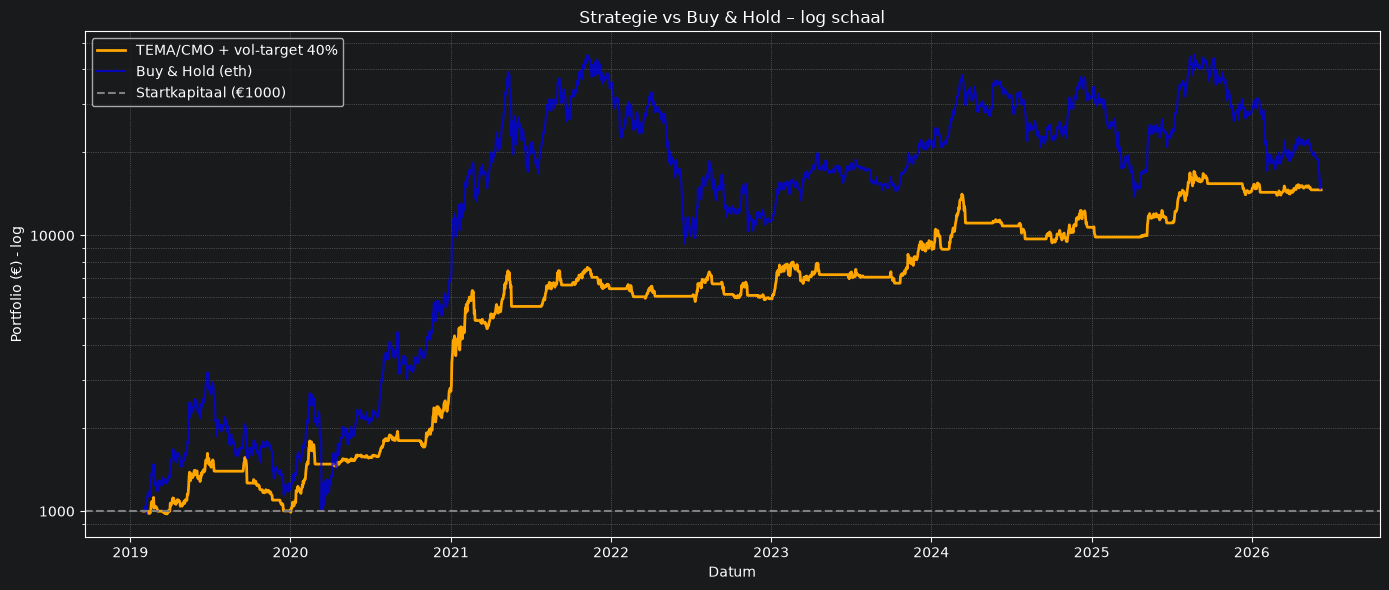

In [9]:
# ============ 6. Equity curve vs Buy & Hold (log) ============
plt.figure(figsize=(14,6))
plt.plot(df_eq.index, df_eq['equity'],   color='orange', lw=2,   label='TEMA/CMO + vol-target 40%')
plt.plot(df_eq.index, df_eq['buy_hold'], color='blue',   lw=1.5, alpha=0.7, label='Buy & Hold (eth)')
plt.axhline(1000, color='gray', ls='--', label='Startkapitaal (\u20ac1000)')
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().yaxis.get_major_formatter().set_scientific(False)
plt.title('Strategie vs Buy & Hold \u2013 log schaal')
plt.xlabel('Datum'); plt.ylabel('Portfolio (\u20ac) - log')
plt.legend(); plt.grid(True, ls=':', alpha=0.6, which='both'); plt.tight_layout(); plt.show()

In [10]:
# ============ 7. Performance dashboard ============
stats = pd.DataFrame(portfolio_history)
stats['peak'] = stats['total_value'].cummax()
stats['dd']   = (stats['total_value'] - stats['peak'])/stats['peak']
max_dd = stats['dd'].min()*100

rets = stats['total_value'].pct_change()
sharpe  = rets.mean()/rets.std()*np.sqrt(365) if rets.std()>0 else 0.0
dside   = rets[rets<0].std()
sortino = rets.mean()/dside*np.sqrt(365) if (dside and dside>0) else 0.0

years = len(stats)/365.0
cagr  = (eind_waarde/1000.0)**(1/years)-1 if eind_waarde>0 else -1.0
calmar = cagr/abs(max_dd/100) if max_dd<0 else 0.0

wins = sum(1 for e,x in trades if x>e)
closed = len(trades)
win_pct = wins/closed*100 if closed else 0.0

bh_final = 1000*df['close'].iloc[-1]/start_price
net_pnl = eind_waarde - 1000.0

print("\U0001f4ca STRATEGIE PERFORMANCE DASHBOARD (vol-target 40%, na fees+slippage)")
print(f"Net PnL: \u20ac{net_pnl:,.0f} | Eindwaarde: \u20ac{eind_waarde:,.0f} | CAGR: {cagr*100:.1f}%")
print(f"Max DD: {abs(max_dd):.1f}% | Sharpe: {sharpe:.2f} | Sortino: {sortino:.2f} | Calmar: {calmar:.2f}")
print(f"Trades: {trade_count} (gesloten: {closed}) | Win%: {win_pct:.1f}%")
print(f"\nBuy & Hold eindwaarde: \u20ac{bh_final:,.0f}")
print(f"Strategie verslaat B&H: {eind_waarde>bh_final}")

📊 STRATEGIE PERFORMANCE DASHBOARD (vol-target 40%, na fees+slippage)
Net PnL: €13,636 | Eindwaarde: €14,636 | CAGR: 44.0%
Max DD: 38.9% | Sharpe: 1.17 | Sortino: 1.27 | Calmar: 1.13
Trades: 34 (gesloten: 34) | Win%: 50.0%

Buy & Hold eindwaarde: €15,849
Strategie verslaat B&H: False
